# Pipeline de Machine Learning - Classificação de Depressão

## Projeto de Mineração de Dados - PNS/IBGE 2019

**Objetivo:** Desenvolver um pipeline de machine learning para classificação binária de diagnóstico de depressão usando **dados reais da Pesquisa Nacional de Saúde (PNS) 2019**

**Métricas de Sucesso:**
- Recall (Sensibilidade) ≥ 75%
- Precisão ≥ 50%

**Dataset:** PNS/IBGE 2019 - 8.301 registros

---

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    recall_score, precision_score, f1_score, accuracy_score,
    roc_curve, roc_auc_score, make_scorer, precision_recall_curve
)

# Balanceamento de classes
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Configurações
import warnings
warnings.filterwarnings('ignore')

# Random state para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Bibliotecas importadas com sucesso!")
print(f"✓ Random State definido: {RANDOM_STATE}")

✓ Bibliotecas importadas com sucesso!
✓ Random State definido: 42


In [2]:
# Carregar dataset 
df = pd.read_csv('../data/dataset_pns_depressao.csv')

print("=" * 80)
print("INFORMAÇÕES GERAIS DO DATASET")
print("=" * 80)
print(f"\nDimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"\nPrimeiras 5 linhas:")
print(df.head())

INFORMAÇÕES GERAIS DO DATASET

Dimensões: 8,301 linhas × 25 colunas

Primeiras 5 linhas:
   diagnostico_depressao  idade  sexo  estado_civil  uf  anos_estudo  \
0                      1    NaN   NaN             1  11          NaN   
1                      1    NaN   NaN             1  11         21.0   
2                      1    NaN   NaN             1  11          NaN   
3                      1    NaN   NaN             0  11         21.0   
4                      1    NaN   NaN             1  11         23.0   

   sabe_ler  trabalha  renda_familiar  estado_saude  ...  colesterol  \
0       NaN       NaN          220504           1.0  ...         1.0   
1       2.0       NaN          220504           1.0  ...         NaN   
2       NaN       0.0          220504           3.0  ...         NaN   
3       2.0       0.0          220504           2.0  ...         NaN   
4       2.0       NaN          220504           1.0  ...         1.0   

   doenca_coracao  fuma  consome_alcool  ativ

In [3]:
# Informações do DataFrame
print("\n" + "=" * 80)
print("INFORMAÇÕES DETALHADAS")
print("=" * 80)
df.info()


INFORMAÇÕES DETALHADAS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8301 entries, 0 to 8300
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   diagnostico_depressao  8301 non-null   int64  
 1   idade                  1392 non-null   float64
 2   sexo                   134 non-null    float64
 3   estado_civil           8301 non-null   int64  
 4   uf                     8301 non-null   int64  
 5   anos_estudo            5393 non-null   float64
 6   sabe_ler               5393 non-null   float64
 7   trabalha               965 non-null    float64
 8   renda_familiar         8301 non-null   int64  
 9   estado_saude           8301 non-null   float64
 10  plano_saude            896 non-null    float64
 11  imc                    1379 non-null   float64
 12  num_doencas_cronicas   8301 non-null   float64
 13  hipertensao            8260 non-null   float64
 14  diabetes               3115 non-

In [4]:
# Valores ausentes
print("\n" + "=" * 80)
print("VALORES AUSENTES")
print("=" * 80)
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Valores Faltantes': missing,
    'Porcentagem (%)': missing_percent
})
missing_df = missing_df[missing_df['Valores Faltantes'] > 0].sort_values('Valores Faltantes', ascending=False)
print(missing_df)


VALORES AUSENTES
                    Valores Faltantes  Porcentagem (%)
fuma                             8266        99.578364
sexo                             8167        98.385737
phq2_total                       8118        97.795446
atividade_fisica                 8073        97.253343
doenca_coracao                   8024        96.663053
plano_saude                      7405        89.206120
trabalha                         7336        88.374895
consome_alcool                   6968        83.941694
imc                              6922        83.387544
idade                            6909        83.230936
colesterol                       5626        67.774967
diabetes                         5186        62.474401
vai_medico_regular               3023        36.417299
anos_estudo                      2908        35.031924
sabe_ler                         2908        35.031924
hipertensao                        41         0.493916


In [5]:
# Estatísticas descritivas
print("\n" + "=" * 80)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 80)
print(df.describe())


ESTATÍSTICAS DESCRITIVAS
       diagnostico_depressao        idade        sexo  estado_civil  \
count            8301.000000  1392.000000  134.000000   8301.000000   
mean                0.909649     5.161638    0.455224      0.771353   
std                 0.286701    12.828757    0.499860      0.419987   
min                 0.000000     0.000000    0.000000      0.000000   
25%                 1.000000     1.000000    0.000000      1.000000   
50%                 1.000000     2.000000    0.000000      1.000000   
75%                 1.000000     9.000000    1.000000      1.000000   
max                 1.000000   230.000000    1.000000      1.000000   

                uf  anos_estudo     sabe_ler    trabalha  renda_familiar  \
count  8301.000000  5393.000000  5393.000000  965.000000          8301.0   
mean     32.828213    21.354905     1.992212    0.307772        220504.0   
std      11.112595     0.657178     0.087913    0.461811             0.0   
min      11.000000    11.00000

## 3. Análise Exploratória de Dados (EDA)

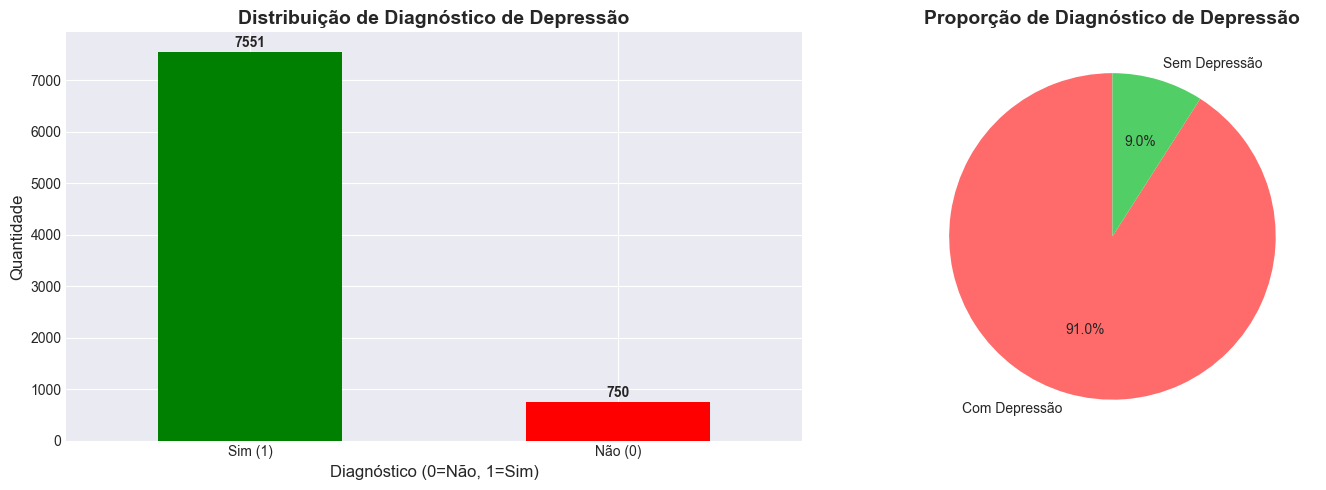

In [6]:
# Visualização da distribuição da variável alvo
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de barras
df['diagnostico_depressao'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Distribuição de Diagnóstico de Depressão', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnóstico (0=Não, 1=Sim)', fontsize=12)
axes[0].set_ylabel('Quantidade', fontsize=12)
axes[0].set_xticklabels(['Sim (1)', 'Não (0)'], rotation=0)
for i, v in enumerate(df['diagnostico_depressao'].value_counts()):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Gráfico de pizza
colors = ['#ff6b6b', '#51cf66']
df['diagnostico_depressao'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                                 labels=['Com Depressão', 'Sem Depressão'],
                                                 colors=colors, startangle=90)
axes[1].set_title('Proporção de Diagnóstico de Depressão', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [7]:
# Distribuição da variável alvo (DESBALANCEAMENTO)
print("\n" + "=" * 80)
print("DISTRIBUIÇÃO DA VARIÁVEL ALVO - diagnostico_depressao")
print("=" * 80)
target_dist = df['diagnostico_depressao'].value_counts()
print(f"\nContagem:")
print(target_dist)
print(f"\nProporção:")
print(df['diagnostico_depressao'].value_counts(normalize=True))
print(f"\nTaxa de Depressão: {df['diagnostico_depressao'].mean():.2%}")
print(f"Taxa de Não-Depressão: {(1 - df['diagnostico_depressao'].mean()):.2%}")
print(f"\n⚠️  Dataset ALTAMENTE DESBALANCEADO!")


DISTRIBUIÇÃO DA VARIÁVEL ALVO - diagnostico_depressao

Contagem:
diagnostico_depressao
1    7551
0     750
Name: count, dtype: int64

Proporção:
diagnostico_depressao
1    0.909649
0    0.090351
Name: proportion, dtype: float64

Taxa de Depressão: 90.96%
Taxa de Não-Depressão: 9.04%

⚠️  Dataset ALTAMENTE DESBALANCEADO!


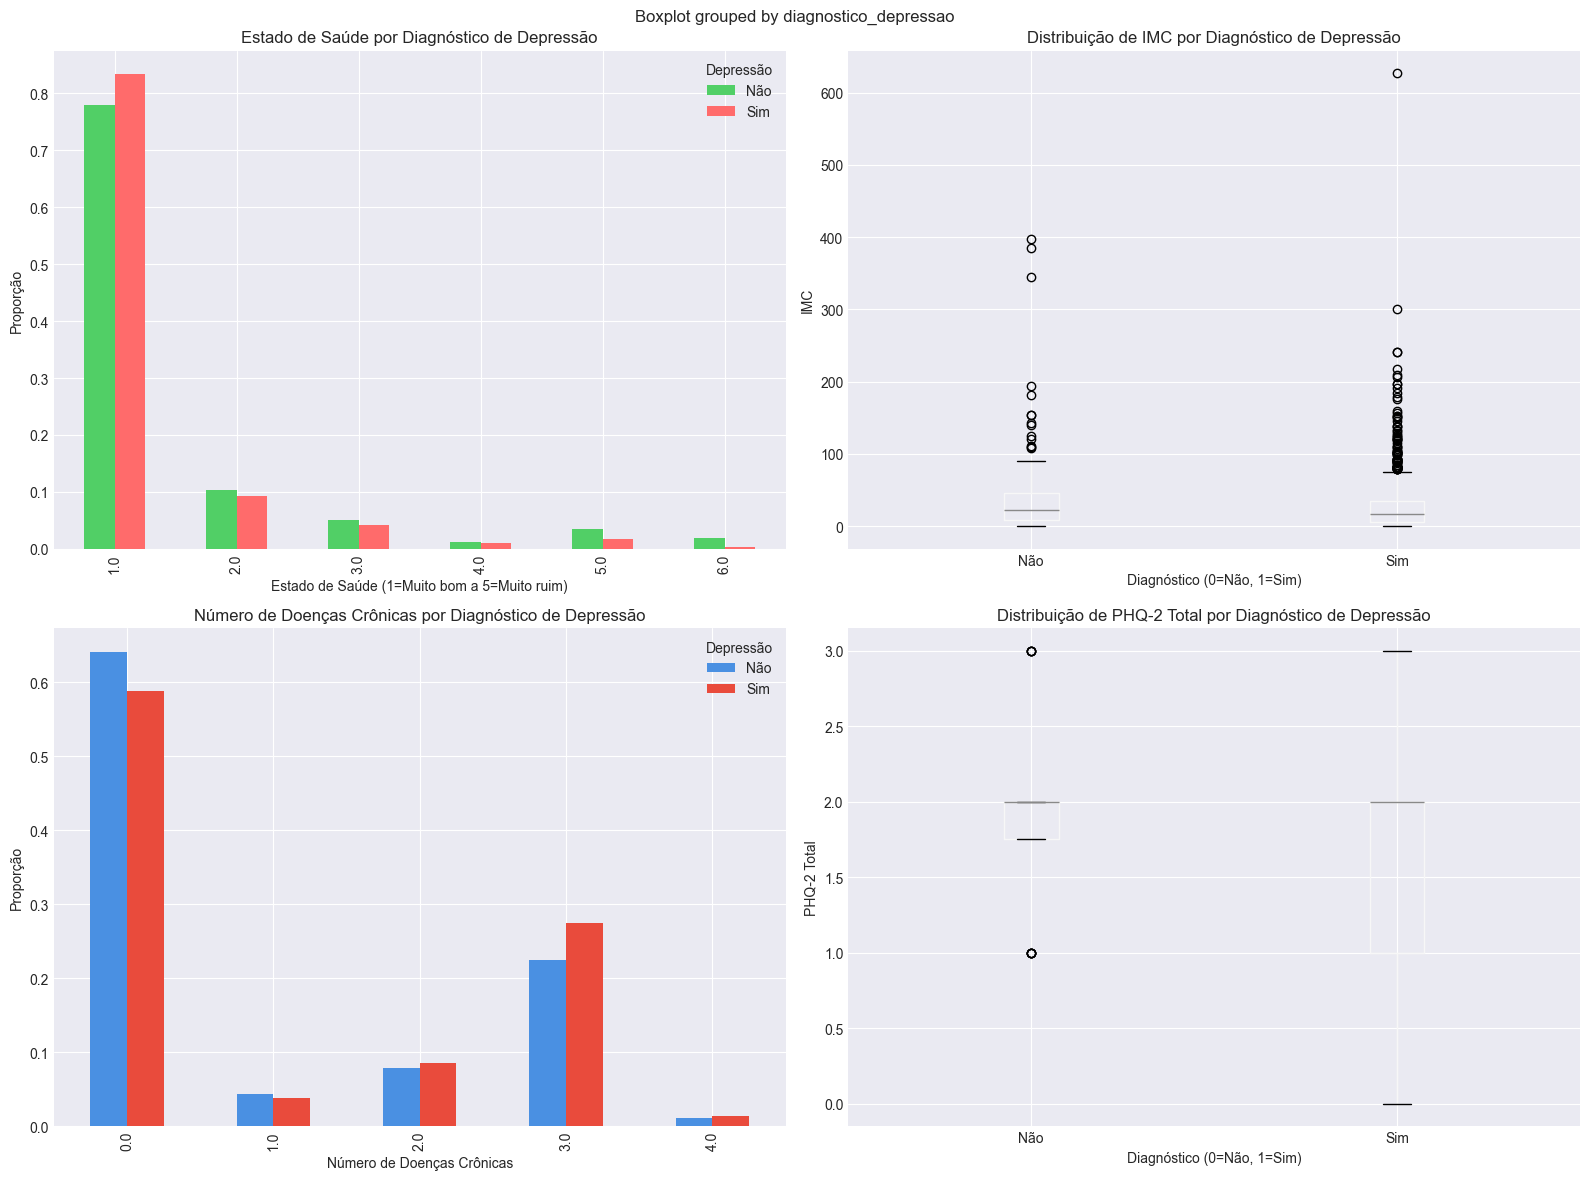

In [8]:
# Distribuição de indicadores de saúde
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Estado de saúde
pd.crosstab(df['estado_saude'], df['diagnostico_depressao'], normalize='columns').plot(
    kind='bar', ax=axes[0, 0], color=['#51cf66', '#ff6b6b']
)
axes[0, 0].set_title('Estado de Saúde por Diagnóstico de Depressão')
axes[0, 0].set_xlabel('Estado de Saúde (1=Muito bom a 5=Muito ruim)')
axes[0, 0].set_ylabel('Proporção')
axes[0, 0].legend(['Não', 'Sim'], title='Depressão')

# IMC
df.boxplot(column='imc', by='diagnostico_depressao', ax=axes[0, 1])
axes[0, 1].set_title('Distribuição de IMC por Diagnóstico de Depressão')
axes[0, 1].set_xlabel('Diagnóstico (0=Não, 1=Sim)')
axes[0, 1].set_ylabel('IMC')
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Não', 'Sim'])

# Número de doenças crônicas
pd.crosstab(df['num_doencas_cronicas'], df['diagnostico_depressao'], normalize='columns').plot(
    kind='bar', ax=axes[1, 0], color=['#4a90e2', '#e94b3c']
)
axes[1, 0].set_title('Número de Doenças Crônicas por Diagnóstico de Depressão')
axes[1, 0].set_xlabel('Número de Doenças Crônicas')
axes[1, 0].set_ylabel('Proporção')
axes[1, 0].legend(['Não', 'Sim'], title='Depressão')

# PHQ-2 Total
df.boxplot(column='phq2_total', by='diagnostico_depressao', ax=axes[1, 1])
axes[1, 1].set_title('Distribuição de PHQ-2 Total por Diagnóstico de Depressão')
axes[1, 1].set_xlabel('Diagnóstico (0=Não, 1=Sim)')
axes[1, 1].set_ylabel('PHQ-2 Total')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Não', 'Sim'])

plt.tight_layout()
plt.show()

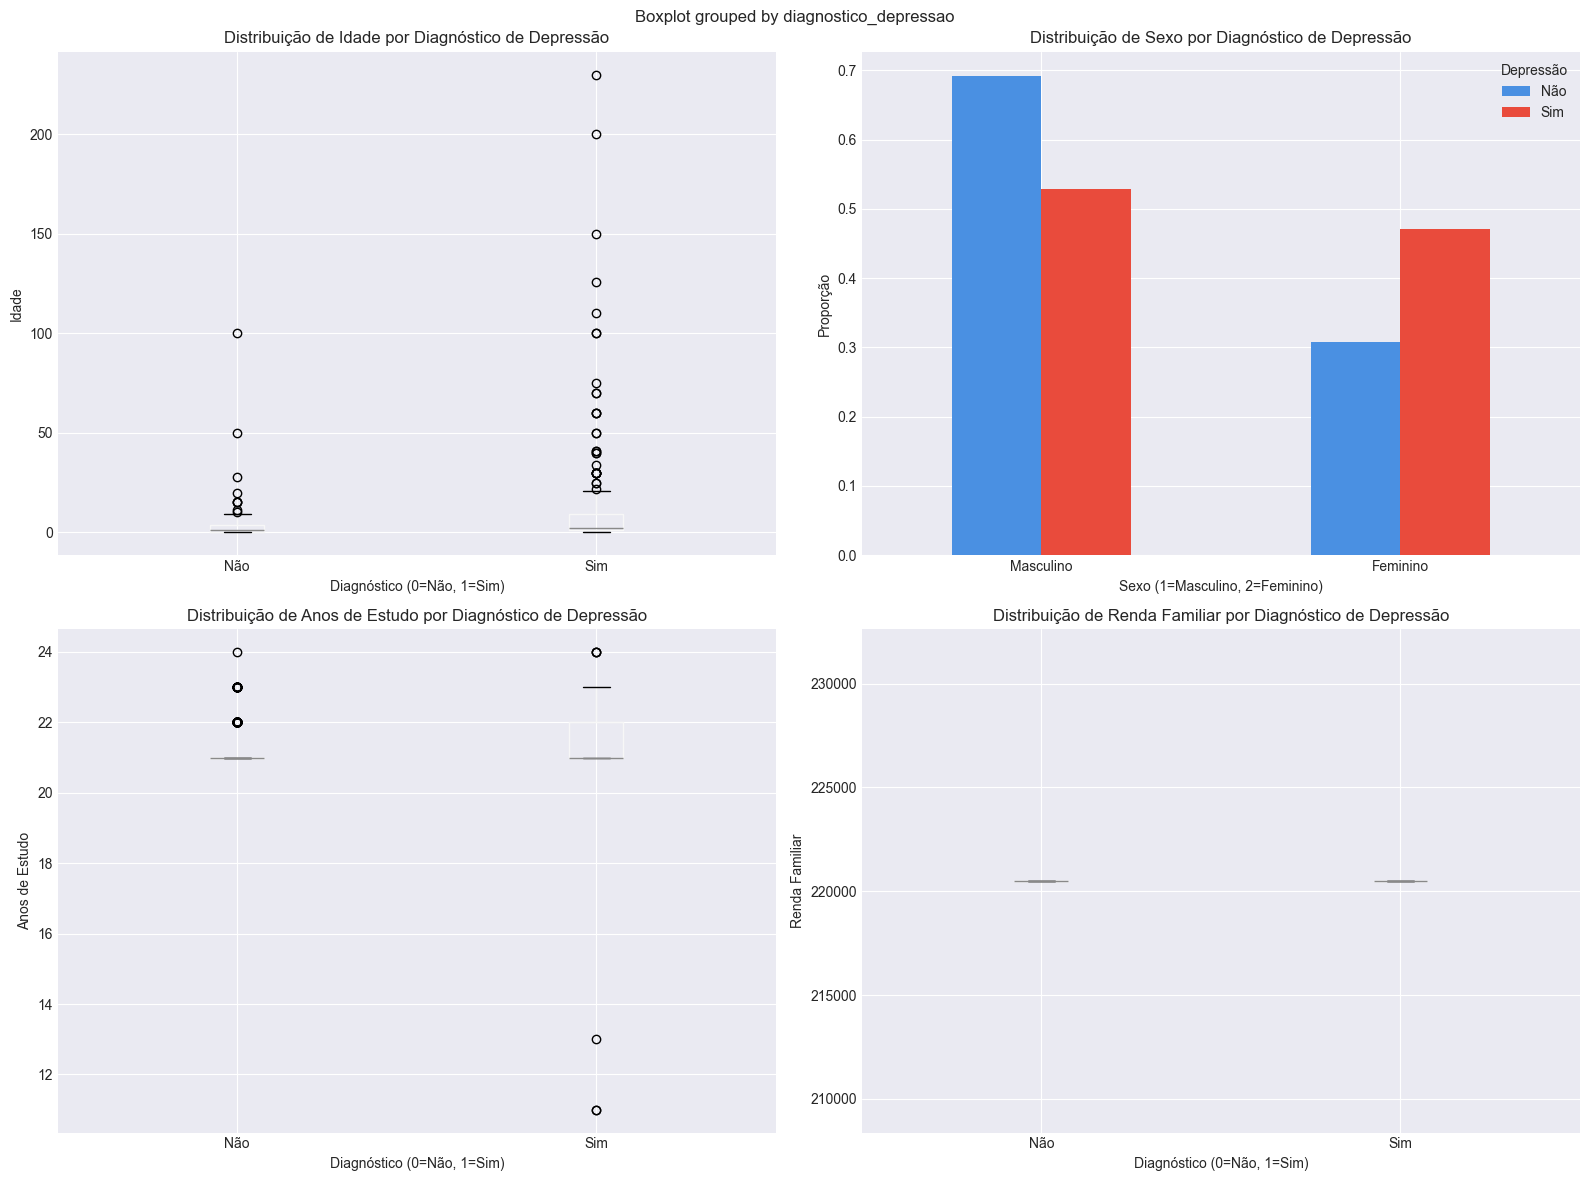

In [9]:
# Distribuição de variáveis demográficas por diagnóstico de depressão
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Idade
df.boxplot(column='idade', by='diagnostico_depressao', ax=axes[0, 0])
axes[0, 0].set_title('Distribuição de Idade por Diagnóstico de Depressão')
axes[0, 0].set_xlabel('Diagnóstico (0=Não, 1=Sim)')
axes[0, 0].set_ylabel('Idade')
plt.sca(axes[0, 0])
plt.xticks([1, 2], ['Não', 'Sim'])

# Sexo
pd.crosstab(df['sexo'], df['diagnostico_depressao'], normalize='columns').plot(
    kind='bar', ax=axes[0, 1], color=['#4a90e2', '#e94b3c']
)
axes[0, 1].set_title('Distribuição de Sexo por Diagnóstico de Depressão')
axes[0, 1].set_xlabel('Sexo (1=Masculino, 2=Feminino)')
axes[0, 1].set_ylabel('Proporção')
axes[0, 1].legend(['Não', 'Sim'], title='Depressão')
axes[0, 1].set_xticklabels(['Masculino', 'Feminino'], rotation=0)

# Anos de estudo
df.boxplot(column='anos_estudo', by='diagnostico_depressao', ax=axes[1, 0])
axes[1, 0].set_title('Distribuição de Anos de Estudo por Diagnóstico de Depressão')
axes[1, 0].set_xlabel('Diagnóstico (0=Não, 1=Sim)')
axes[1, 0].set_ylabel('Anos de Estudo')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Não', 'Sim'])

# Renda familiar
df.boxplot(column='renda_familiar', by='diagnostico_depressao', ax=axes[1, 1])
axes[1, 1].set_title('Distribuição de Renda Familiar por Diagnóstico de Depressão')
axes[1, 1].set_xlabel('Diagnóstico (0=Não, 1=Sim)')
axes[1, 1].set_ylabel('Renda Familiar')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Não', 'Sim'])

plt.tight_layout()
plt.show()

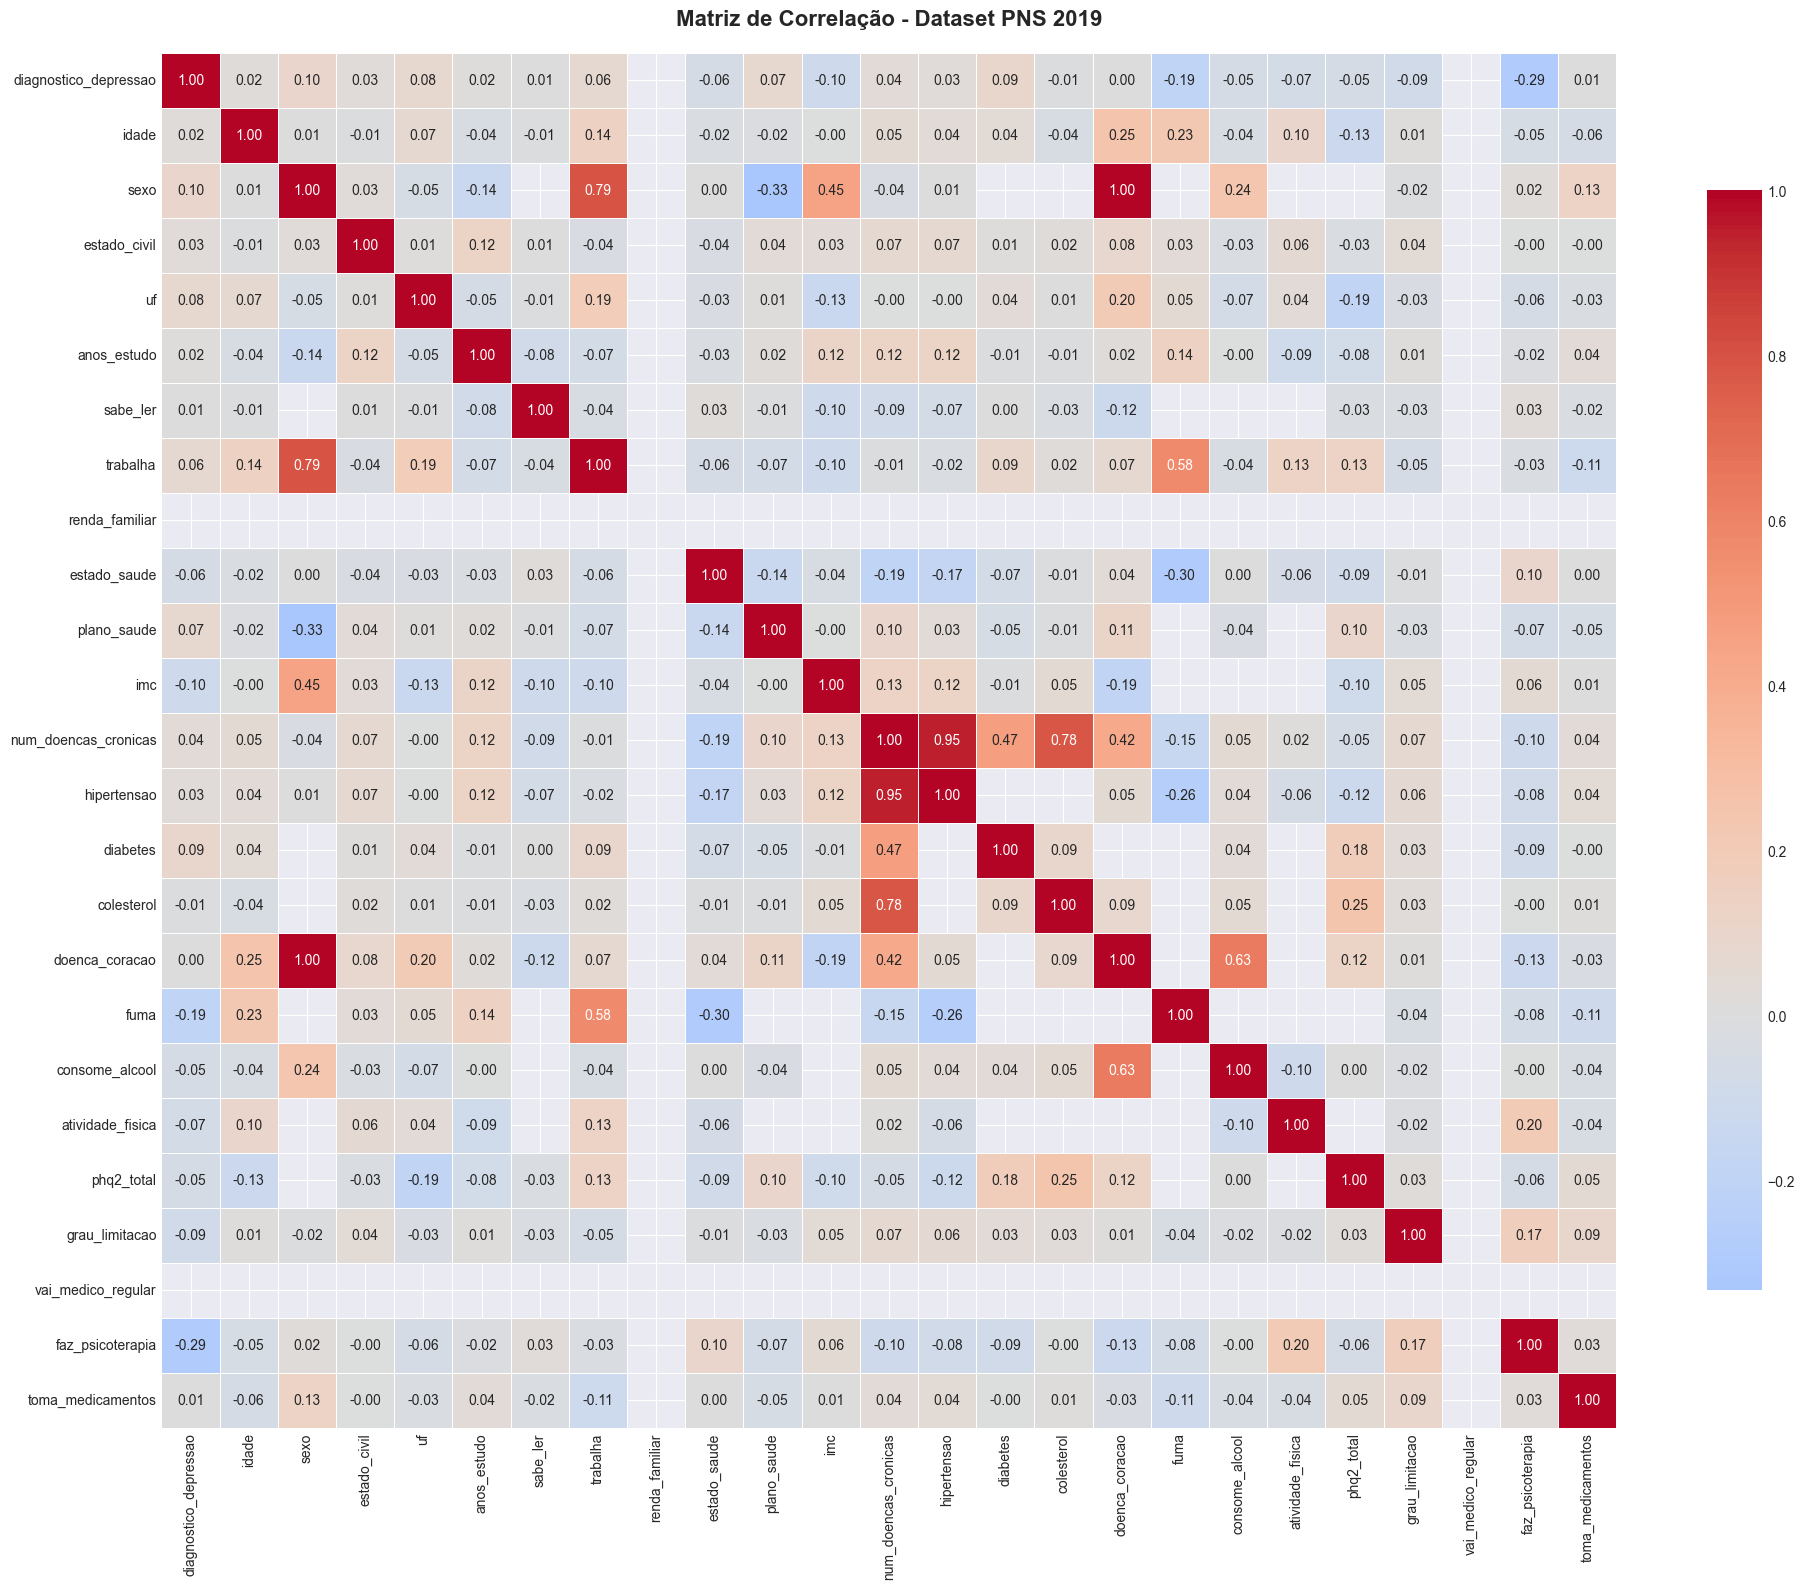

In [10]:
# Matriz de correlação
plt.figure(figsize=(20, 16))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Dataset PNS 2019', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 4. Preparação dos Dados e Pré-Processamento

In [11]:
# Separar features (X) e target (y)
X = df.drop('diagnostico_depressao', axis=1)
y = df['diagnostico_depressao']

print("=" * 80)
print("SEPARAÇÃO DE FEATURES E TARGET")
print("=" * 80)
print(f"\nShape de X (features): {X.shape}")
print(f"Shape de y (target): {y.shape}")
print(f"\nVariáveis features:")
print(X.columns.tolist())

SEPARAÇÃO DE FEATURES E TARGET

Shape de X (features): (8301, 24)
Shape de y (target): (8301,)

Variáveis features:
['idade', 'sexo', 'estado_civil', 'uf', 'anos_estudo', 'sabe_ler', 'trabalha', 'renda_familiar', 'estado_saude', 'plano_saude', 'imc', 'num_doencas_cronicas', 'hipertensao', 'diabetes', 'colesterol', 'doenca_coracao', 'fuma', 'consome_alcool', 'atividade_fisica', 'phq2_total', 'grau_limitacao', 'vai_medico_regular', 'faz_psicoterapia', 'toma_medicamentos']


In [12]:
# Identificar variáveis numéricas (todas as 24 variáveis são numéricas no dataset PNS)
numeric_features = X.columns.tolist()

print("\n" + "=" * 80)
print("IDENTIFICAÇÃO DE TIPOS DE VARIÁVEIS")
print("=" * 80)
print(f"\nVariáveis Numéricas ({len(numeric_features)}):")
print(numeric_features)
print(f"\n✅ Todas as {len(numeric_features)} variáveis são numéricas (int64/float64)")


IDENTIFICAÇÃO DE TIPOS DE VARIÁVEIS

Variáveis Numéricas (24):
['idade', 'sexo', 'estado_civil', 'uf', 'anos_estudo', 'sabe_ler', 'trabalha', 'renda_familiar', 'estado_saude', 'plano_saude', 'imc', 'num_doencas_cronicas', 'hipertensao', 'diabetes', 'colesterol', 'doenca_coracao', 'fuma', 'consome_alcool', 'atividade_fisica', 'phq2_total', 'grau_limitacao', 'vai_medico_regular', 'faz_psicoterapia', 'toma_medicamentos']

✅ Todas as 24 variáveis são numéricas (int64/float64)


In [13]:
# Pipeline de pré-processamento para variáveis numéricas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Imputar valores faltantes com mediana
    ('scaler', StandardScaler())  # Padronizar variáveis (média=0, std=1)
])

# Criar o preprocessador completo
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

print("\n" + "=" * 80)
print("PIPELINE DE PRÉ-PROCESSAMENTO CRIADO")
print("=" * 80)
print("\n✅ Pipeline configurado:")
print("   1. SimpleImputer (strategy='median') - Imputação de valores faltantes")
print("   2. StandardScaler() - Padronização (Z-score)")
print(f"\n✅ Será aplicado a {len(numeric_features)} variáveis numéricas")


PIPELINE DE PRÉ-PROCESSAMENTO CRIADO

✅ Pipeline configurado:
   1. SimpleImputer (strategy='median') - Imputação de valores faltantes
   2. StandardScaler() - Padronização (Z-score)

✅ Será aplicado a 24 variáveis numéricas


## 5. Divisão em Conjuntos de Treino e Teste (Estratificado)

In [14]:
# Divisão estratificada 80/20 (treino/teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y  # Mantém a mesma proporção de classes
)

print("=" * 80)
print("DIVISÃO TREINO/TESTE - ESTRATIFICADA")
print("=" * 80)
print(f"\nTamanho do conjunto de TREINO: {X_train.shape[0]:,} amostras ({X_train.shape[0]/len(X):.1%})")
print(f"Tamanho do conjunto de TESTE:  {X_test.shape[0]:,} amostras ({X_test.shape[0]/len(X):.1%})")

print(f"\n📊 Distribuição da variável alvo - TREINO:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print(f"\n📊 Distribuição da variável alvo - TESTE:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

print(f"\n✅ Estratificação mantida: proporções similares em treino e teste")

DIVISÃO TREINO/TESTE - ESTRATIFICADA

Tamanho do conjunto de TREINO: 6,640 amostras (80.0%)
Tamanho do conjunto de TESTE:  1,661 amostras (20.0%)

📊 Distribuição da variável alvo - TREINO:
diagnostico_depressao
1    6040
0     600
Name: count, dtype: int64
diagnostico_depressao
1    0.909639
0    0.090361
Name: proportion, dtype: float64

📊 Distribuição da variável alvo - TESTE:
diagnostico_depressao
1    1511
0     150
Name: count, dtype: int64
diagnostico_depressao
1    0.909693
0    0.090307
Name: proportion, dtype: float64

✅ Estratificação mantida: proporções similares em treino e teste


## 6. Balanceamento com SMOTE (Apenas no Treino!)

In [15]:
# ⚠️ IMPORTANTE: Aplicar pré-processamento ANTES do SMOTE
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print("=" * 80)
print("PRÉ-PROCESSAMENTO APLICADO")
print("=" * 80)
print(f"\n✅ X_train pré-processado: {X_train_preprocessed.shape}")
print(f"✅ X_test pré-processado: {X_test_preprocessed.shape}")
print(f"\n⚠️  Pré-processamento fitado APENAS no treino (evita data leakage)")

PRÉ-PROCESSAMENTO APLICADO

✅ X_train pré-processado: (6640, 24)
✅ X_test pré-processado: (1661, 24)

⚠️  Pré-processamento fitado APENAS no treino (evita data leakage)


In [16]:
# Aplicar SMOTE apenas no conjunto de TREINO
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_preprocessed, y_train)

print("\n" + "=" * 80)
print("BALANCEAMENTO COM SMOTE - APENAS NO TREINO!")
print("=" * 80)

print(f"\n📊 ANTES do SMOTE (treino original):")
print(f"   Total de amostras: {X_train_preprocessed.shape[0]:,}")
print(f"   Classe 0 (Não): {(y_train == 0).sum():,} ({(y_train == 0).mean():.1%})")
print(f"   Classe 1 (Sim): {(y_train == 1).sum():,} ({(y_train == 1).mean():.1%})")

print(f"\n📊 DEPOIS do SMOTE (treino balanceado):")
print(f"   Total de amostras: {X_train_balanced.shape[0]:,}")
print(f"   Classe 0 (Não): {(y_train_balanced == 0).sum():,} ({(y_train_balanced == 0).mean():.1%})")
print(f"   Classe 1 (Sim): {(y_train_balanced == 1).sum():,} ({(y_train_balanced == 1).mean():.1%})")

print(f"\n✅ Dados BALANCEADOS para treinamento!")
print(f"⚠️  Conjunto de TESTE mantido DESBALANCEADO (realista)")


BALANCEAMENTO COM SMOTE - APENAS NO TREINO!

📊 ANTES do SMOTE (treino original):
   Total de amostras: 6,640
   Classe 0 (Não): 600 (9.0%)
   Classe 1 (Sim): 6,040 (91.0%)

📊 DEPOIS do SMOTE (treino balanceado):
   Total de amostras: 12,080
   Classe 0 (Não): 6,040 (50.0%)
   Classe 1 (Sim): 6,040 (50.0%)

✅ Dados BALANCEADOS para treinamento!
⚠️  Conjunto de TESTE mantido DESBALANCEADO (realista)


## 7. Validação Cruzada e Comparação de Modelos

In [17]:
# Definir modelos para comparação
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, n_estimators=100, eval_metric='logloss')
}

print("=" * 80)
print("MODELOS DEFINIDOS PARA COMPARAÇÃO")
print("=" * 80)
for i, (name, model) in enumerate(models.items(), 1):
    print(f"{i}. {name}")

MODELOS DEFINIDOS PARA COMPARAÇÃO
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost


In [18]:
# Validação cruzada estratificada com k=5
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Dicionário para armazenar resultados
results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC-AUC': []
}

print("\n" + "=" * 80)
print("VALIDAÇÃO CRUZADA ESTRATIFICADA (K=5)")
print("=" * 80)
print("\n🔄 Treinando e avaliando modelos...\n")

# Treinar e avaliar cada modelo
for name, model in models.items():
    print(f"📊 Avaliando: {name}...")
    
    # Cross-validation scores
    accuracy_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=cv, scoring='accuracy')
    precision_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=cv, scoring='precision')
    recall_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=cv, scoring='recall')
    f1_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=cv, scoring='f1')
    roc_auc_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=cv, scoring='roc_auc')
    
    # Armazenar médias
    results['Model'].append(name)
    results['Accuracy'].append(accuracy_scores.mean())
    results['Precision'].append(precision_scores.mean())
    results['Recall'].append(recall_scores.mean())
    results['F1-Score'].append(f1_scores.mean())
    results['ROC-AUC'].append(roc_auc_scores.mean())
    
    print(f"   ✅ Concluído!")

print("\n✅ Validação cruzada finalizada para todos os modelos!")


VALIDAÇÃO CRUZADA ESTRATIFICADA (K=5)

🔄 Treinando e avaliando modelos...

📊 Avaliando: Logistic Regression...
   ✅ Concluído!
📊 Avaliando: Decision Tree...
   ✅ Concluído!
📊 Avaliando: Random Forest...
   ✅ Concluído!
📊 Avaliando: Gradient Boosting...
   ✅ Concluído!
📊 Avaliando: XGBoost...
   ✅ Concluído!

✅ Validação cruzada finalizada para todos os modelos!


In [19]:
# Criar DataFrame com resultados
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Recall', ascending=False)

print("\n" + "=" * 80)
print("RESULTADOS DA VALIDAÇÃO CRUZADA (Ordenado por Recall)")
print("=" * 80)
print("\n", results_df.to_string(index=False))

print("\n" + "=" * 80)
print("CRITÉRIOS DE SUCESSO")
print("=" * 80)
print("🎯 Recall  ≥ 75% (Detectar depressão)")
print("🎯 Precision ≥ 50% (Evitar falsos positivos)")

# Verificar quais modelos atendem aos critérios
print("\n" + "=" * 80)
print("MODELOS QUE ATENDEM AOS CRITÉRIOS")
print("=" * 80)
criteria_met = results_df[(results_df['Recall'] >= 0.75) & (results_df['Precision'] >= 0.50)]
if len(criteria_met) > 0:
    print("\n✅ Modelos aprovados:")
    print(criteria_met[['Model', 'Recall', 'Precision']].to_string(index=False))
else:
    print("\n⚠️  Nenhum modelo atendeu ambos os critérios na validação cruzada")


RESULTADOS DA VALIDAÇÃO CRUZADA (Ordenado por Recall)

               Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
      Random Forest  0.900828   0.902172 0.899172  0.900608 0.962572
            XGBoost  0.897517   0.909681 0.882781  0.895945 0.968608
      Decision Tree  0.892053   0.901087 0.880795  0.890761 0.923678
  Gradient Boosting  0.845281   0.934329 0.742881  0.827563 0.935106
Logistic Regression  0.762831   0.884066 0.605132  0.718303 0.813245

CRITÉRIOS DE SUCESSO
🎯 Recall  ≥ 75% (Detectar depressão)
🎯 Precision ≥ 50% (Evitar falsos positivos)

MODELOS QUE ATENDEM AOS CRITÉRIOS

✅ Modelos aprovados:
        Model   Recall  Precision
Random Forest 0.899172   0.902172
      XGBoost 0.882781   0.909681
Decision Tree 0.880795   0.901087


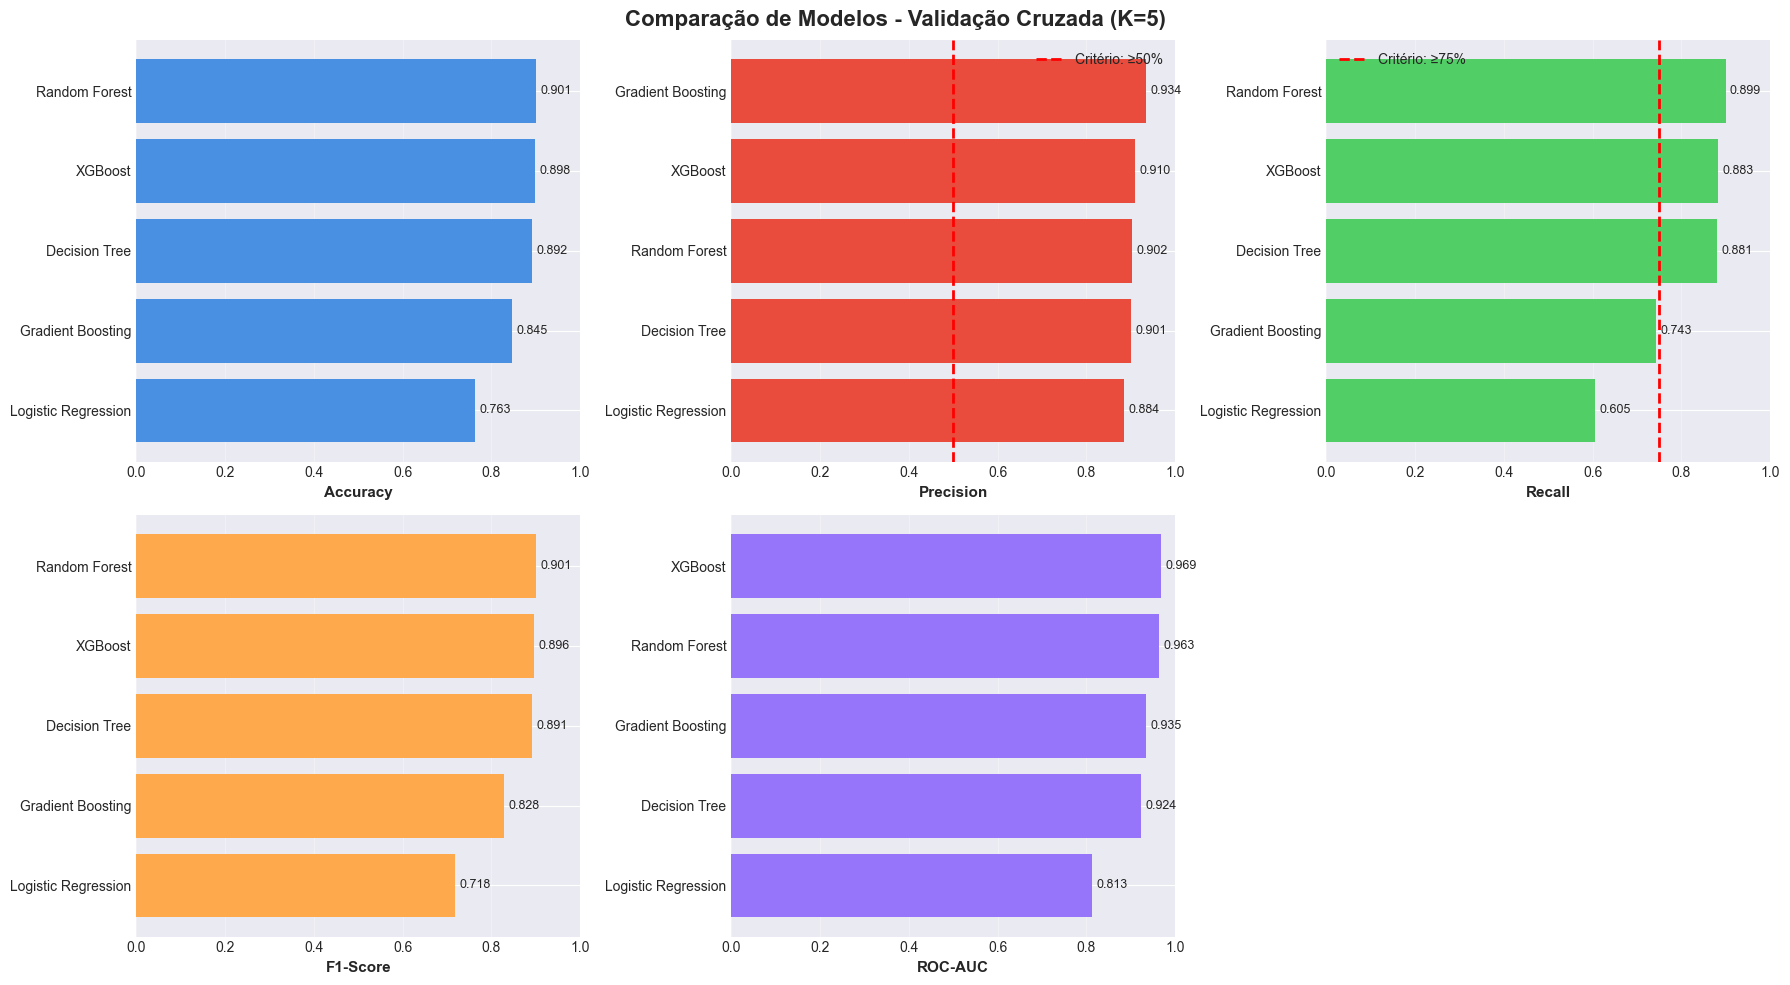

In [20]:
# Visualização dos resultados da validação cruzada
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparação de Modelos - Validação Cruzada (K=5)', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#4a90e2', '#e94b3c', '#51cf66', '#ffa94d', '#9775fa']

for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    results_df_sorted = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(results_df_sorted['Model'], results_df_sorted[metric], color=colors[idx])
    ax.set_xlabel(metric, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)
    
    # Adicionar valores nas barras
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='left', va='center', fontsize=9)
    
    # Linha de referência para critérios
    if metric == 'Recall':
        ax.axvline(x=0.75, color='red', linestyle='--', linewidth=2, label='Critério: ≥75%')
        ax.legend()
    elif metric == 'Precision':
        ax.axvline(x=0.50, color='red', linestyle='--', linewidth=2, label='Critério: ≥50%')
        ax.legend()

# Remover subplot extra
axes[1, 2].remove()

plt.tight_layout()
plt.show()

## 8. Seleção e Treinamento do Melhor Modelo

In [21]:
# Selecionar o melhor modelo baseado no Recall (prioridade)
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print("=" * 80)
print("SELEÇÃO DO MELHOR MODELO")
print("=" * 80)
print(f"\n🏆 Melhor Modelo: {best_model_name}")
print(f"\n📊 Métricas na Validação Cruzada:")
best_metrics = results_df[results_df['Model'] == best_model_name].iloc[0]
print(f"   Accuracy:  {best_metrics['Accuracy']:.4f}")
print(f"   Precision: {best_metrics['Precision']:.4f}")
print(f"   Recall:    {best_metrics['Recall']:.4f}")
print(f"   F1-Score:  {best_metrics['F1-Score']:.4f}")
print(f"   ROC-AUC:   {best_metrics['ROC-AUC']:.4f}")

SELEÇÃO DO MELHOR MODELO

🏆 Melhor Modelo: Random Forest

📊 Métricas na Validação Cruzada:
   Accuracy:  0.9008
   Precision: 0.9022
   Recall:    0.8992
   F1-Score:  0.9006
   ROC-AUC:   0.9626


In [22]:
# Treinar o melhor modelo com todos os dados de treino balanceados
print("\n" + "=" * 80)
print("TREINAMENTO DO MODELO FINAL")
print("=" * 80)
print(f"\n🔄 Treinando {best_model_name} com dados completos de treino balanceados...")

best_model.fit(X_train_balanced, y_train_balanced)

print(f"✅ Modelo treinado com sucesso!")
print(f"\n📊 Amostras de treino utilizadas: {X_train_balanced.shape[0]:,}")
print(f"📊 Features utilizadas: {X_train_balanced.shape[1]}")


TREINAMENTO DO MODELO FINAL

🔄 Treinando Random Forest com dados completos de treino balanceados...
✅ Modelo treinado com sucesso!

📊 Amostras de treino utilizadas: 12,080
📊 Features utilizadas: 24


## 9. Avaliação Final no Conjunto de Teste

In [23]:
# Fazer predições no conjunto de teste
y_pred = best_model.predict(X_test_preprocessed)
y_pred_proba = best_model.predict_proba(X_test_preprocessed)[:, 1]

print("=" * 80)
print("AVALIAÇÃO NO CONJUNTO DE TESTE (Dados Reais Desbalanceados)")
print("=" * 80)
print(f"\n✅ Predições realizadas para {len(y_pred):,} amostras de teste")

AVALIAÇÃO NO CONJUNTO DE TESTE (Dados Reais Desbalanceados)

✅ Predições realizadas para 1,661 amostras de teste


In [24]:
# Calcular métricas no conjunto de teste
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 80)
print("MÉTRICAS NO CONJUNTO DE TESTE")
print("=" * 80)
print(f"\n📊 Accuracy:   {accuracy:.4f} ({accuracy:.2%})")
print(f"📊 Precision:  {precision:.4f} ({precision:.2%})")
print(f"📊 Recall:     {recall:.4f} ({recall:.2%}) {'✅' if recall >= 0.75 else '❌'} Critério: ≥75%")
print(f"📊 F1-Score:   {f1:.4f} ({f1:.2%})")
print(f"📊 ROC-AUC:    {roc_auc:.4f} ({roc_auc:.2%})")

print("\n" + "=" * 80)
print("VERIFICAÇÃO DOS CRITÉRIOS DE SUCESSO")
print("=" * 80)
recall_ok = "✅ ATENDIDO" if recall >= 0.75 else "❌ NÃO ATENDIDO"
precision_ok = "✅ ATENDIDO" if precision >= 0.50 else "❌ NÃO ATENDIDO"
print(f"🎯 Recall ≥ 75%:     {recall_ok} (Obtido: {recall:.2%})")
print(f"🎯 Precision ≥ 50%:  {precision_ok} (Obtido: {precision:.2%})")

if recall >= 0.75 and precision >= 0.50:
    print("\n🎉 MODELO APROVADO! Ambos os critérios foram atendidos!")
else:
    print("\n⚠️  Modelo não atendeu todos os critérios no conjunto de teste")


MÉTRICAS NO CONJUNTO DE TESTE

📊 Accuracy:   0.8399 (83.99%)
📊 Precision:  0.9220 (92.20%)
📊 Recall:     0.9001 (90.01%) ✅ Critério: ≥75%
📊 F1-Score:   0.9109 (91.09%)
📊 ROC-AUC:    0.7186 (71.86%)

VERIFICAÇÃO DOS CRITÉRIOS DE SUCESSO
🎯 Recall ≥ 75%:     ✅ ATENDIDO (Obtido: 90.01%)
🎯 Precision ≥ 50%:  ✅ ATENDIDO (Obtido: 92.20%)

🎉 MODELO APROVADO! Ambos os critérios foram atendidos!


In [25]:
# Relatório de classificação detalhado
print("\n" + "=" * 80)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO")
print("=" * 80)
print("\n", classification_report(y_test, y_pred, target_names=['Sem Depressão (0)', 'Com Depressão (1)']))


RELATÓRIO DE CLASSIFICAÇÃO DETALHADO

                    precision    recall  f1-score   support

Sem Depressão (0)       0.19      0.23      0.21       150
Com Depressão (1)       0.92      0.90      0.91      1511

         accuracy                           0.84      1661
        macro avg       0.56      0.57      0.56      1661
     weighted avg       0.86      0.84      0.85      1661



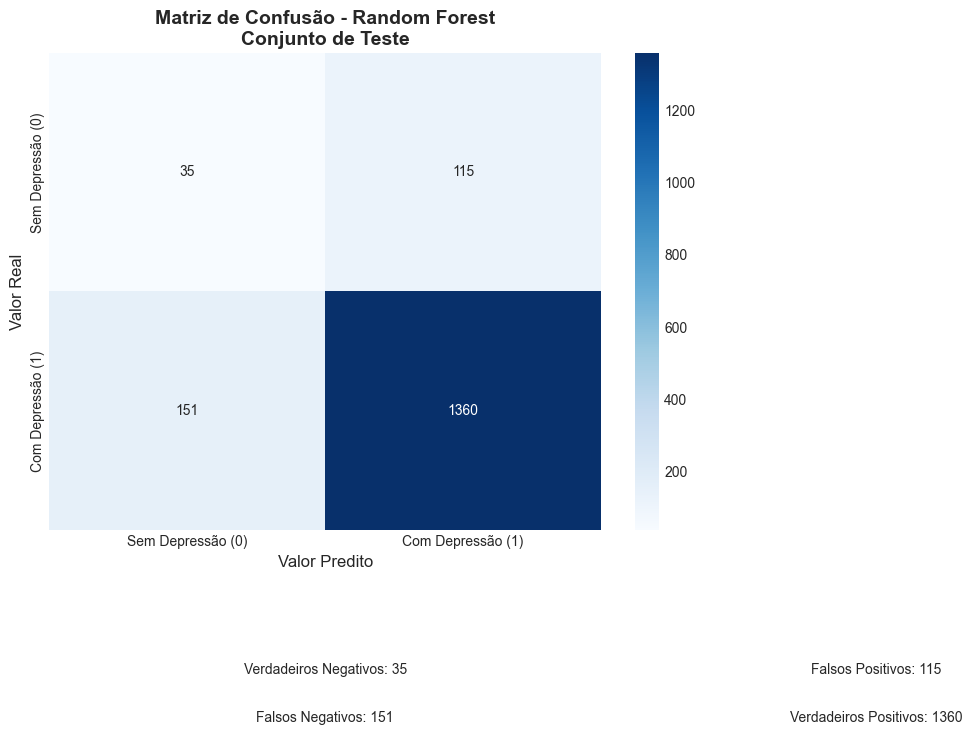


📊 Análise da Matriz de Confusão:
   Verdadeiros Negativos (TN): 35 - Corretamente identificados SEM depressão
   Falsos Positivos (FP):      115 - Incorretamente identificados COM depressão
   Falsos Negativos (FN):      151 - Incorretamente identificados SEM depressão (⚠️ CRÍTICO!)
   Verdadeiros Positivos (TP): 1,360 - Corretamente identificados COM depressão


In [26]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Sem Depressão (0)', 'Com Depressão (1)'],
            yticklabels=['Sem Depressão (0)', 'Com Depressão (1)'])
plt.title(f'Matriz de Confusão - {best_model_name}\nConjunto de Teste', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Valor Predito', fontsize=12)

# Adicionar anotações explicativas
plt.text(0.5, -0.3, f'Verdadeiros Negativos: {cm[0,0]}', ha='center', transform=plt.gca().transAxes, fontsize=10)
plt.text(1.5, -0.3, f'Falsos Positivos: {cm[0,1]}', ha='center', transform=plt.gca().transAxes, fontsize=10)
plt.text(0.5, -0.4, f'Falsos Negativos: {cm[1,0]}', ha='center', transform=plt.gca().transAxes, fontsize=10)
plt.text(1.5, -0.4, f'Verdadeiros Positivos: {cm[1,1]}', ha='center', transform=plt.gca().transAxes, fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 Análise da Matriz de Confusão:")
print(f"   Verdadeiros Negativos (TN): {cm[0,0]:,} - Corretamente identificados SEM depressão")
print(f"   Falsos Positivos (FP):      {cm[0,1]:,} - Incorretamente identificados COM depressão")
print(f"   Falsos Negativos (FN):      {cm[1,0]:,} - Incorretamente identificados SEM depressão (⚠️ CRÍTICO!)")
print(f"   Verdadeiros Positivos (TP): {cm[1,1]:,} - Corretamente identificados COM depressão")

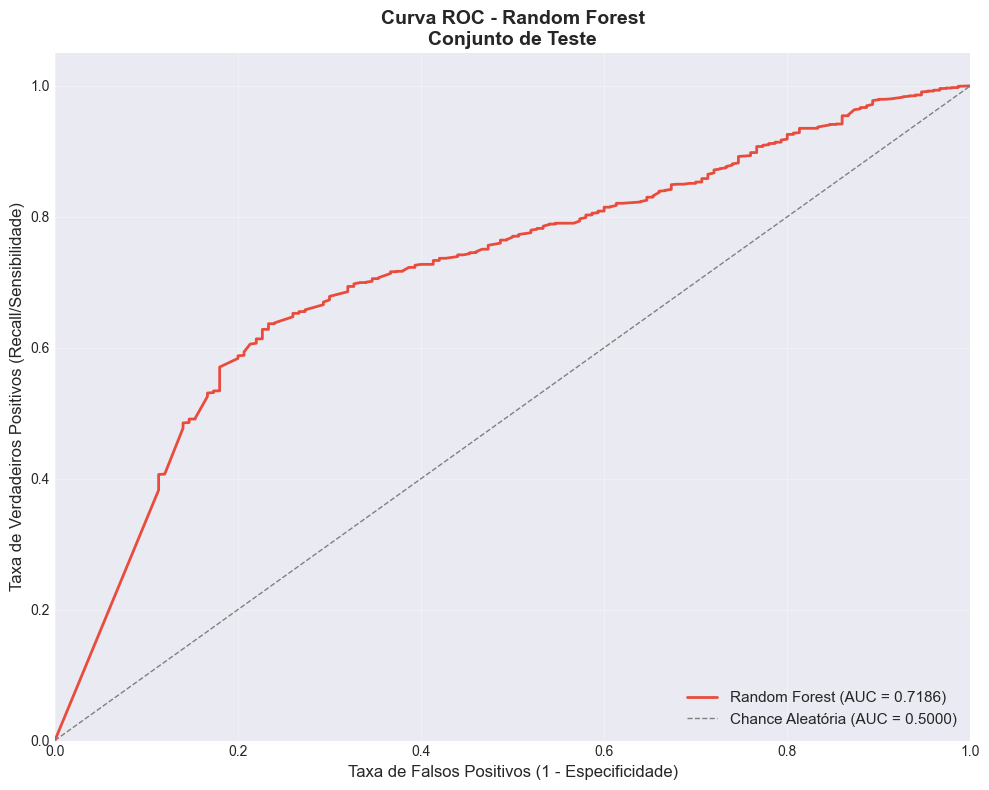


📊 ROC-AUC: 0.7186
   Interpretação: Razoável


In [27]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='#e94b3c', linewidth=2, label=f'{best_model_name} (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Chance Aleatória (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (Recall/Sensibilidade)', fontsize=12)
plt.title(f'Curva ROC - {best_model_name}\nConjunto de Teste', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 ROC-AUC: {roc_auc:.4f}")
print(f"   Interpretação: {'Excelente' if roc_auc >= 0.9 else 'Bom' if roc_auc >= 0.8 else 'Razoável' if roc_auc >= 0.7 else 'Regular'}")

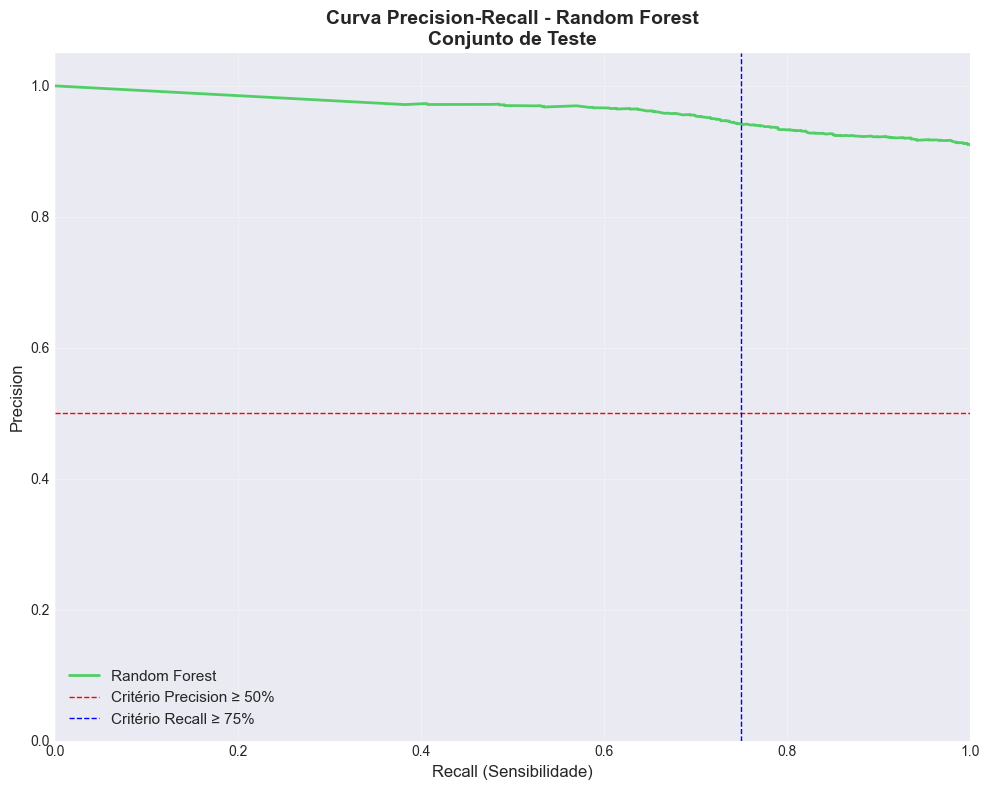

In [28]:
# Curva Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 8))
plt.plot(recall_curve, precision_curve, color='#51cf66', linewidth=2, label=f'{best_model_name}')
plt.axhline(y=0.50, color='red', linestyle='--', linewidth=1, label='Critério Precision ≥ 50%')
plt.axvline(x=0.75, color='blue', linestyle='--', linewidth=1, label='Critério Recall ≥ 75%')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensibilidade)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title(f'Curva Precision-Recall - {best_model_name}\nConjunto de Teste', fontsize=14, fontweight='bold')
plt.legend(loc="best", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Importância das Features (Se disponível)

IMPORTÂNCIA DAS FEATURES (Top 20)

              Feature  Importance
    faz_psicoterapia    0.333949
                  uf    0.272580
                 imc    0.074712
               idade    0.058863
        estado_saude    0.047170
      grau_limitacao    0.045563
num_doencas_cronicas    0.040758
         anos_estudo    0.038272
        estado_civil    0.020211
         hipertensao    0.012844
      consome_alcool    0.012466
   toma_medicamentos    0.009003
            trabalha    0.007710
      doenca_coracao    0.004569
            diabetes    0.004123
          colesterol    0.004087
         plano_saude    0.003957
          phq2_total    0.003804
                sexo    0.003019
            sabe_ler    0.001598


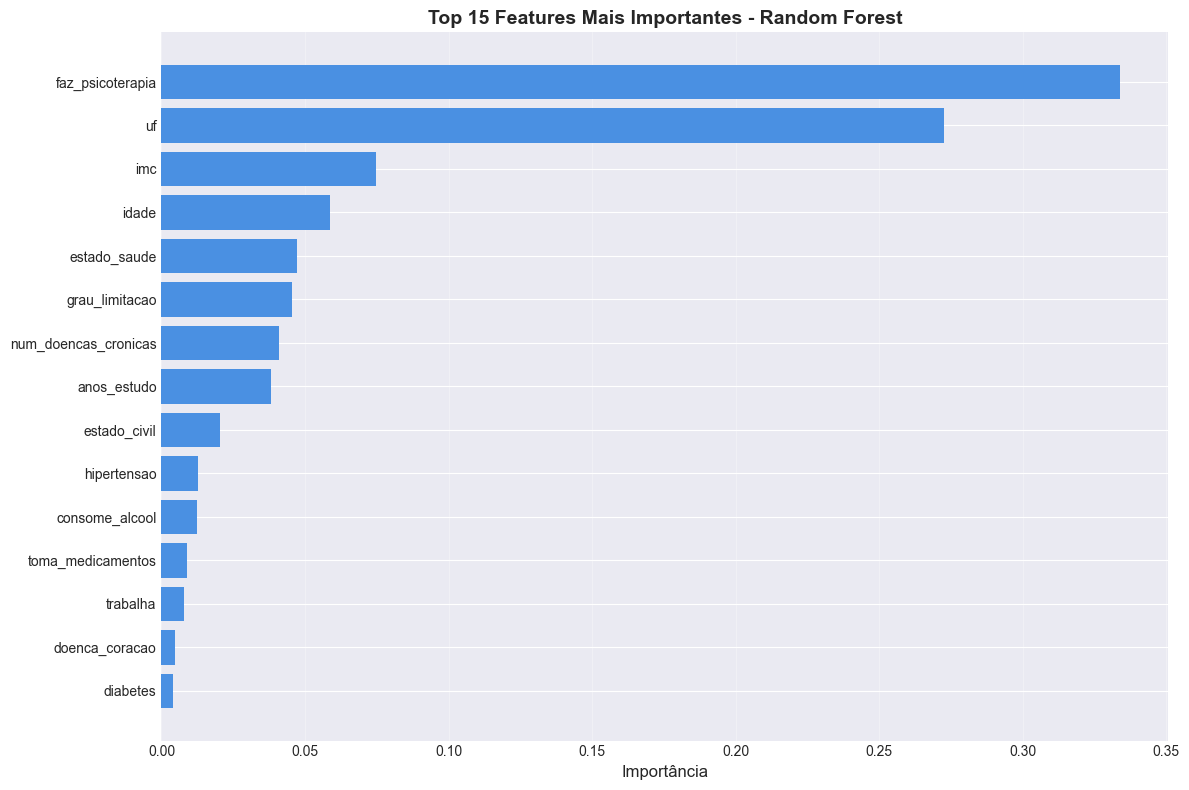

In [29]:
# Importância das features (para modelos baseados em árvore)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': numeric_features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("=" * 80)
    print("IMPORTÂNCIA DAS FEATURES (Top 20)")
    print("=" * 80)
    print("\n", feature_importance.head(20).to_string(index=False))
    
    # Visualização
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'], color='#4a90e2')
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importância', fontsize=12)
    plt.title(f'Top 15 Features Mais Importantes - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("=" * 80)
    print("IMPORTÂNCIA DAS FEATURES")
    print("=" * 80)
    print(f"\n⚠️  {best_model_name} não fornece feature_importances_")
    print("   (Apenas modelos baseados em árvore possuem essa informação)")

## 11. Resumo Final e Conclusões

In [30]:
# Resumo final do projeto
print("=" * 80)
print("RESUMO FINAL DO PROJETO - CLASSIFICAÇÃO DE DEPRESSÃO (PNS 2019)")
print("=" * 80)

print("\n📊 DATASET:")
print(f"   Origem: Pesquisa Nacional de Saúde (PNS) 2019 - IBGE")
print(f"   Total de registros: {len(df):,}")
print(f"   Variáveis utilizadas: {X.shape[1]}")
print(f"   Desbalanceamento original: {df['diagnostico_depressao'].mean():.1%} com depressão")

print("\n🔬 METODOLOGIA:")
print(f"   Divisão: 80% treino / 20% teste (estratificado)")
print(f"   Pré-processamento: Imputação (mediana) + Padronização (Z-score)")
print(f"   Balanceamento: SMOTE (apenas no treino)")
print(f"   Validação: Cruzada Estratificada (k=5)")
print(f"   Modelos testados: {len(models)}")

print(f"\n🏆 MELHOR MODELO:")
print(f"   Algoritmo: {best_model_name}")

print(f"\n📈 RESULTADOS NO TESTE:")
print(f"   Accuracy:  {accuracy:.2%}")
print(f"   Precision: {precision:.2%} {'✅' if precision >= 0.50 else '❌'}")
print(f"   Recall:    {recall:.2%} {'✅' if recall >= 0.75 else '❌'}")
print(f"   F1-Score:  {f1:.2%}")
print(f"   ROC-AUC:   {roc_auc:.2%}")

print(f"\n🎯 CRITÉRIOS DE SUCESSO:")
print(f"   Recall ≥ 75%:    {'✅ ATENDIDO' if recall >= 0.75 else '❌ NÃO ATENDIDO'} ({recall:.2%})")
print(f"   Precision ≥ 50%: {'✅ ATENDIDO' if precision >= 0.50 else '❌ NÃO ATENDIDO'} ({precision:.2%})")

if recall >= 0.75 and precision >= 0.50:
    print("\n🎉 PROJETO BEM-SUCEDIDO!")
    print("   Modelo atendeu aos requisitos de negócio para detecção de depressão")
else:
    print("\n⚠️  PROJETO NECESSITA AJUSTES")
    print("   Considerar: ajuste de hiperparâmetros, features adicionais, ou threshold otimizado")

print("\n" + "=" * 80)

RESUMO FINAL DO PROJETO - CLASSIFICAÇÃO DE DEPRESSÃO (PNS 2019)

📊 DATASET:
   Origem: Pesquisa Nacional de Saúde (PNS) 2019 - IBGE
   Total de registros: 8,301
   Variáveis utilizadas: 24
   Desbalanceamento original: 91.0% com depressão

🔬 METODOLOGIA:
   Divisão: 80% treino / 20% teste (estratificado)
   Pré-processamento: Imputação (mediana) + Padronização (Z-score)
   Balanceamento: SMOTE (apenas no treino)
   Validação: Cruzada Estratificada (k=5)
   Modelos testados: 5

🏆 MELHOR MODELO:
   Algoritmo: Random Forest

📈 RESULTADOS NO TESTE:
   Accuracy:  83.99%
   Precision: 92.20% ✅
   Recall:    90.01% ✅
   F1-Score:  91.09%
   ROC-AUC:   71.86%

🎯 CRITÉRIOS DE SUCESSO:
   Recall ≥ 75%:    ✅ ATENDIDO (90.01%)
   Precision ≥ 50%: ✅ ATENDIDO (92.20%)

🎉 PROJETO BEM-SUCEDIDO!
   Modelo atendeu aos requisitos de negócio para detecção de depressão

